In [271]:
from astropy.io import fits

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import stats as ss
from scipy.io import readsav
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA

from tqdm import tqdm

import tools as t

## Extract data

In [318]:
# load files
path_data = '../data/sim_series/'
N_files = 20  # 20 temporal series (from 0 to 19), need to check file N°20
data_spectra = []
data_rv = []
for i in range(N_files):
    data_spectra.append(fits.getdata(path_data + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie{i}.fits'))
    data_rv.append(readsav(path_data + f'res_rv_bis_6173_lionel_tau1_scaling1_sansrot_serie{i}.sav'))
data_spectra = np.array(data_spectra)
data_rv = np.array(data_rv)
# wavelength and time arrays
wl = np.array(data_rv[0]['lambd'])  # same wavelength grid for all time series (verified)
times = np.arange(0, len(data_spectra[0]) * 144, 144) / 60 / 24  # time in days, same for all time series
times_sec = times * 86400
data_rv[0].keys()

dict_keys(['rv_gauss', 'rv_correl', 'rv_deriv', 'xbiss', 'ybiss', 'l_true', 'lambd', 'flux_moy'])

In [319]:
# calculate radial velocity by template 
mean_spec = np.array([np.mean(i, axis=0) for i in data_spectra])  # list of N_files mean spectra
d_S0 = np.array([np.gradient(i, wl) for i in mean_spec])  # derivative of the mean spectra
C_0 = 1000
rv_tm = []
for j in range(N_files):  # iterate over each time series
    rv_j = []
    for k in range(len(times)):  # for each spectrum
        rv_j.append(t.calculate_rv(wl, mean_spec[j], data_spectra[j][k], C_0))
    rv_tm.append(np.array(rv_j))
rv_tm = np.array(rv_tm)

In [320]:
# add noise to data_spectra
snr = 5000
sigma = 1 / snr
data_noisy = []
for ts in data_spectra:
    ts_noisy = np.array([i + np.random.normal(0, sigma, len(wl)) for i in ts])
    data_noisy.append(ts_noisy)

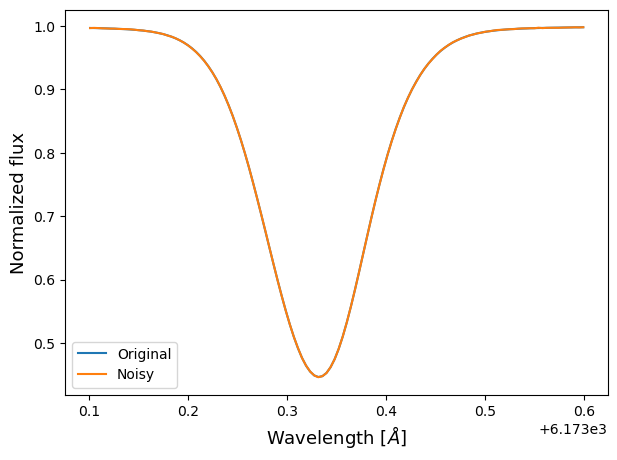

In [321]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(wl, data_spectra[0][0], label='Original')
ax.plot(wl, data_noisy[0][0], label='Noisy')
ax.set_xlabel(r'Wavelength [$\AA$]', size=13)
ax.set_ylabel('Normalized flux', size=13)
ax.legend()
plt.show()

In [322]:
# redefine data_spectra to simplify the rest of the code
data_spectra = np.array(data_noisy)

data_spectra[ i ]: matrix with 3686 spectra of 122 elements each \
data_rv[ i ]: dictionary

In [323]:
S_f = []  # array of spectra matrices
v_vectors = []  # array of velocity vectors

for i in range(N_files):
    # take out projection over the velocity vector
    s, v = t.subtract_v(wl, data_spectra[i], c=3e18)  # speed of light in angstrom/s
    S_f.append(s)
    v_vectors.append(v)

S_f = np.array(S_f)
v_vectors = np.array(v_vectors)

## Apply PCA

In [324]:
# apply double centering to each spectra matrix
spectra_centered = np.array([t.double_centering(i) for i in S_f])

In [325]:
# apply PCA to the centered spectra matrix
n_components = 20

pcs_ts = []  # list of N_files lists of of principal components
loadings_ts = []
scores_ts = []

for i in spectra_centered:  # each is is a double-centered matrix
    pca_flux_i = PCA(n_components=n_components)  # create PCA object
    pcs_i = pca_flux_i.fit_transform(i)            # fit the model with spectra_centered and apply the dimensionality reduction
    pcs_ts.append(pcs_i)
    loadings_ts.append(pca_flux_i.components_)
    scores_ts.append(np.array([pcs_i[:, j] for j in range(n_components)]))

pcs_ts = np.array(pcs_ts)
loadings_ts = np.array(loadings_ts)
scores_ts = np.array(scores_ts)

In [326]:
# make a plot for the three cases
for i in range(N_files):
    for j in range(n_components):
        r, p = ss.pearsonr(scores_ts[i][j], rv_tm[i])
        if np.abs(r) > .5:
            print(f'PC {j+1} from TS {i+1} is correlated with the radial velocity: r={r:.2f}')
            #print(f'pvalue={p}')

PC 1 from TS 1 is correlated with the radial velocity: r=0.94
PC 1 from TS 2 is correlated with the radial velocity: r=0.95
PC 1 from TS 3 is correlated with the radial velocity: r=0.94
PC 1 from TS 4 is correlated with the radial velocity: r=0.94
PC 1 from TS 5 is correlated with the radial velocity: r=0.95
PC 1 from TS 6 is correlated with the radial velocity: r=0.94
PC 1 from TS 7 is correlated with the radial velocity: r=0.95
PC 1 from TS 8 is correlated with the radial velocity: r=0.95
PC 1 from TS 9 is correlated with the radial velocity: r=0.94
PC 1 from TS 10 is correlated with the radial velocity: r=0.94
PC 1 from TS 11 is correlated with the radial velocity: r=0.95
PC 1 from TS 12 is correlated with the radial velocity: r=0.94
PC 1 from TS 13 is correlated with the radial velocity: r=0.94
PC 1 from TS 14 is correlated with the radial velocity: r=0.93
PC 1 from TS 15 is correlated with the radial velocity: r=0.95
PC 1 from TS 16 is correlated with the radial velocity: r=0.94
P

In [281]:
# calculate power spectrum
dt = times[1] - times[0]
file = 10  # pick one file to show components
pcs = pcs_ts[file]
scores = scores_ts[file]
loadings = loadings_ts[file]

# power spectrum
pgs = np.array([t.calculate_periodogram(times_sec, scores[i]) for i in range(n_components)])  # calculate periodograms
ft, ps, freq = pgs[:, 0], pgs[:, 1], pgs[:, 2]  # save FT, PS and frequencies

/home/elefevre-forjan/.conda/envs/internship/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/elefevre-forjan/.conda/envs/internship/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


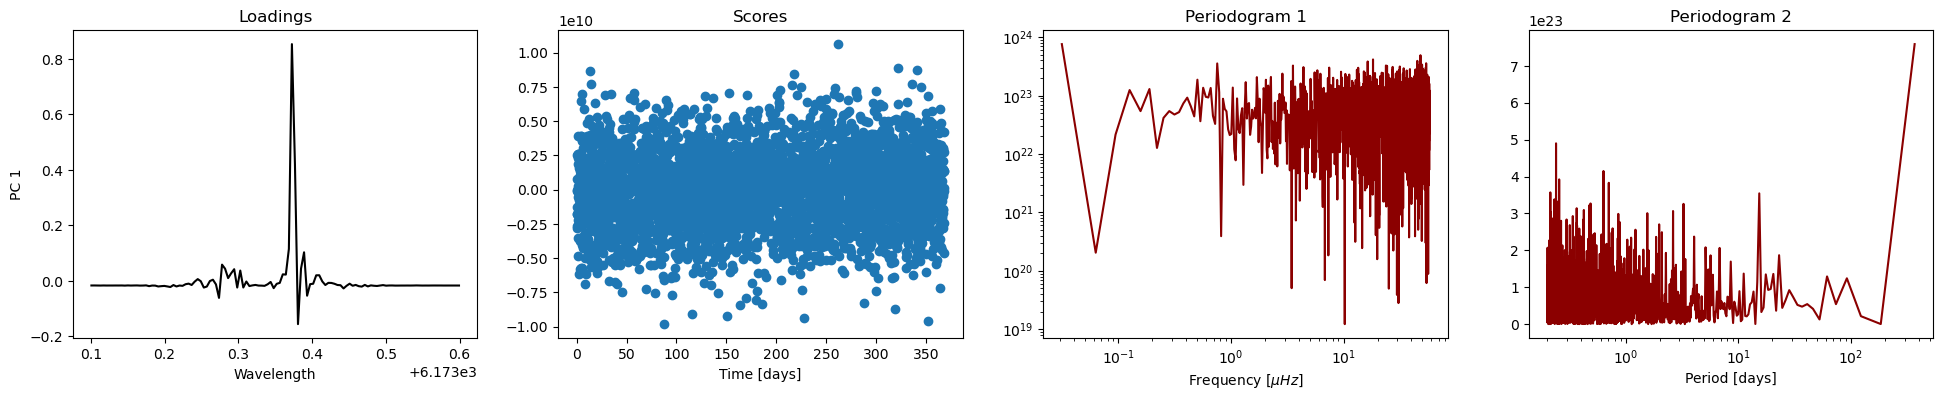

In [241]:
# plot
for i in range(1):
    fig, axs = plt.subplots(1, 4, figsize=(24, 4))
    
    # Loadings
    axs[0].plot(wl, loadings[i], color='k')
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(times, scores[i])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Time [days]')

    # Fourier power spectrum (frequency)
    mask = freq[i] > 0
    axs[2].plot(freq[i][mask] * 10**6, ps[i][mask], color='darkred')  # frequency in Hz, multiplied by 10^6 to pass to microhertz
    axs[2].set_yscale('log')
    axs[2].set_xscale('log')
    axs[2].set_title('Periodogram 1', size=12)
    axs[2].set_xlabel(r'Frequency [$\mu Hz$]')
    
    # Fourier periodogram (period)
    axs[3].plot(1 / freq[i][mask] / 86400, ps[i][mask], color='darkred')  # period in seconds, divided by 86400 to pass to days
    #axs[3].set_yscale('log')
    axs[3].set_xscale('log')
    axs[3].set_title('Periodogram 2', size=12)
    axs[3].set_xlabel('Period [days]')

    plt.show()

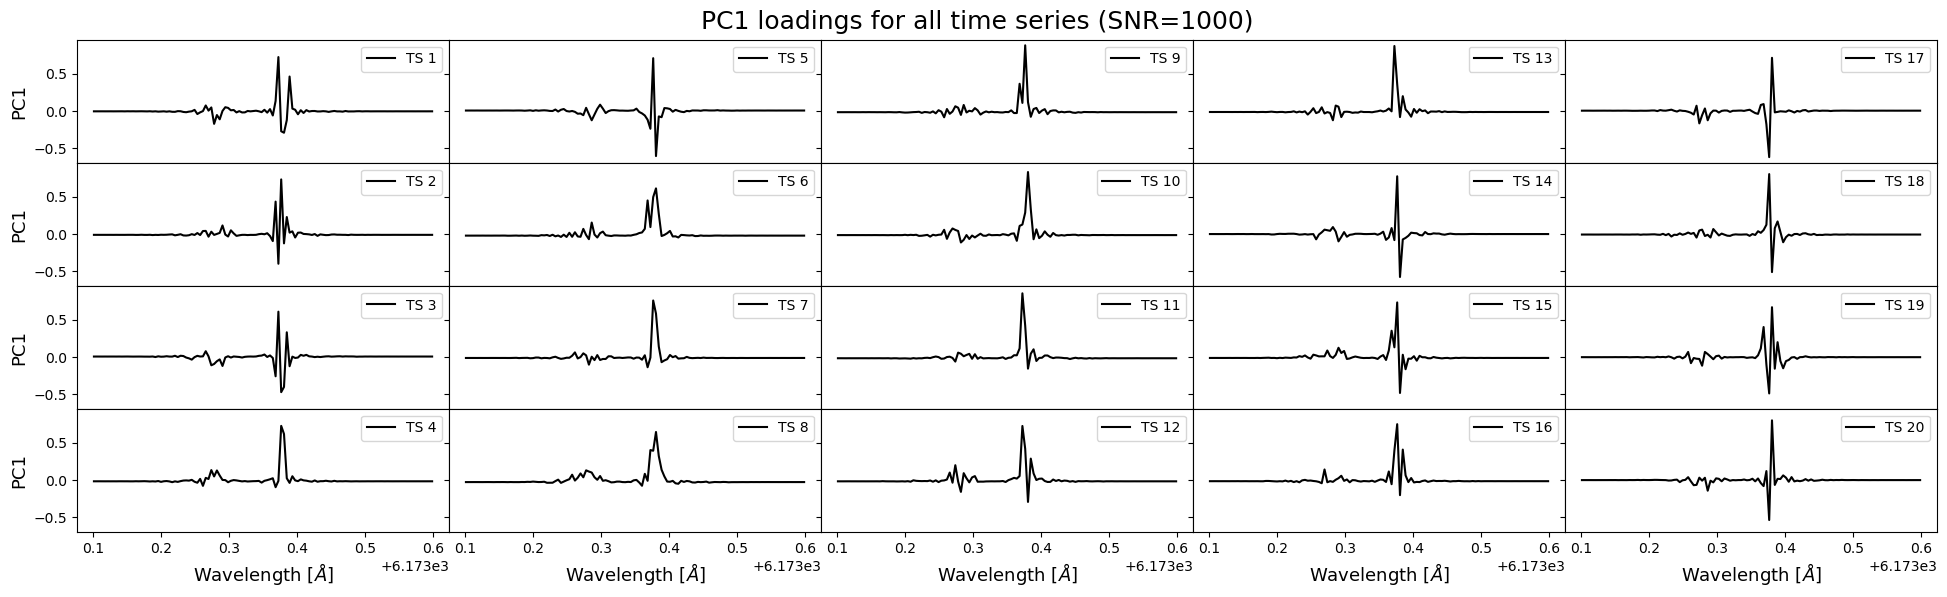

In [242]:
# PC1 loadings have always the same shape?
rows = 4
cols = 5
fig, axs = plt.subplots(rows, cols, figsize=(24, 6), sharex=True, sharey=True)
fig.suptitle(f'PC1 loadings for all time series (SNR={snr})', size=18)

r = 0
k = -1

for i in range(N_files):  # iterate over the N_files time series of spectra
    if i % rows == 0:  # if the column is filled, advance to the next one
        k += 1  # advance to the next column
        r = 0  # reset row
    if k == 0:  # set y-label only in the first column of each row
        axs[r][k].set_ylabel('PC1', size=13)
    if r + 1 == rows:  # set x-label only in the last row of each column
        axs[r][k].set_xlabel(r'Wavelength [$\AA$]', size=13)
    axs[r][k].plot(wl, loadings_ts[i][0], color='k', label=f'TS {i + 1}')
    axs[r][k].legend()
    r += 1  # advance to the next row

plt.subplots_adjust(hspace=0, wspace=0, top=.93)
plt.show()

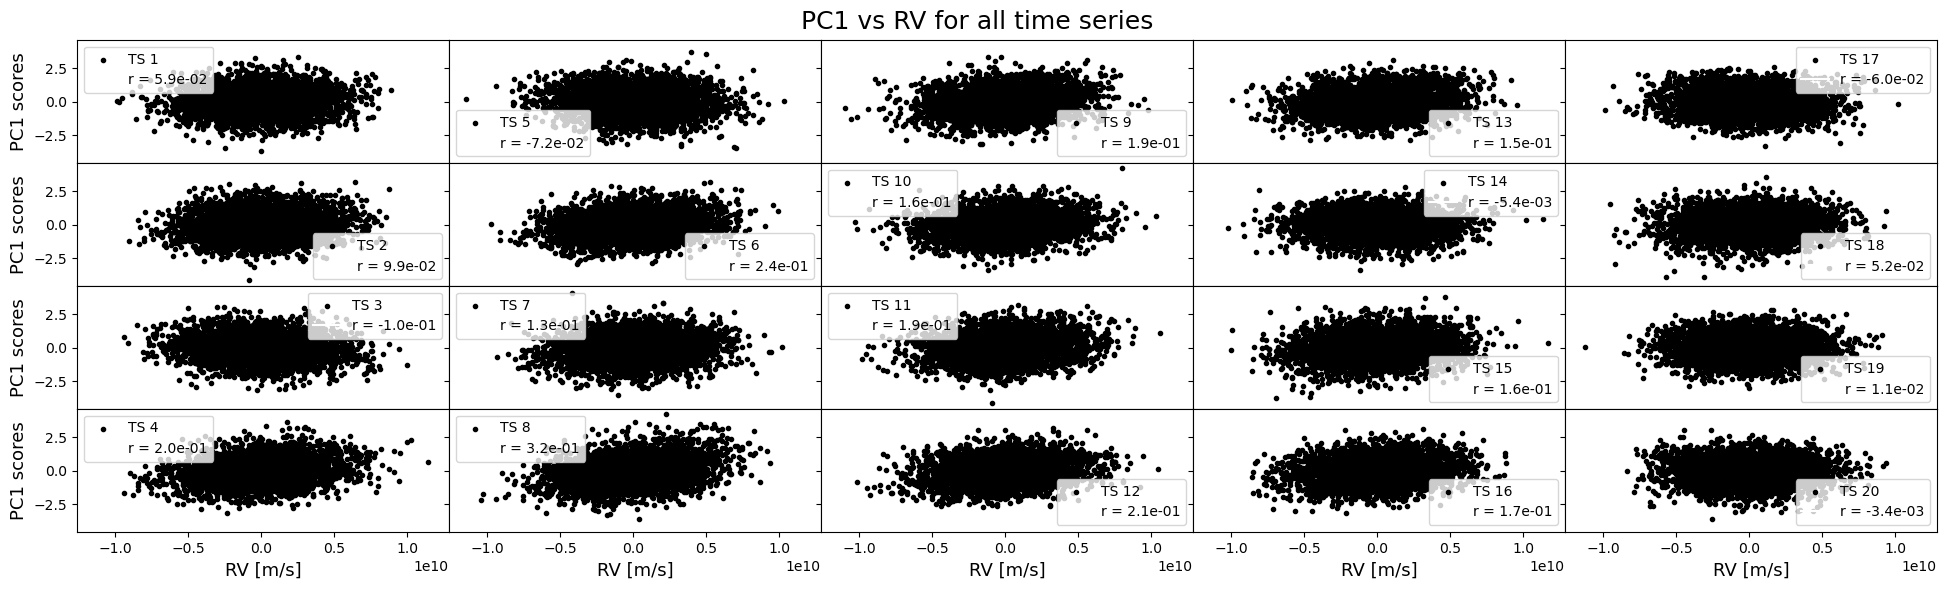

In [243]:
# PC1 always correlated with RV?
rows = 4
cols = 5
fig, axs = plt.subplots(rows, cols, figsize=(24, 6), sharex=True, sharey=True)
fig.suptitle('PC1 vs RV for all time series', size=18)

r = 0
k = -1

# correlation coefficient between RV and PC1
corr_1 = np.array([ss.pearsonr(scores_ts[i][0], rv_tm[i])[0] for i in range(N_files)])

for i in range(N_files):  # iterate over the N_files time series of spectra
    if i % rows == 0:  # if the column is filled, advance to the next one
        k += 1  # advance to the next column
        r = 0  # reset row
    if k == 0:  # set y-label only in the first column of each row
        axs[r][k].set_ylabel('PC1 scores', size=13)
    if r + 1 == rows:  # set x-label only in the last row of each column
        axs[r][k].set_xlabel('RV [m/s]', size=13)
    axs[r][k].scatter(scores_ts[i][0], rv_tm[i], color='k', label=f'TS {i + 1}', marker='.')
    axs[r][k].axvline(0, color='w', label=f'r = {corr_1[i]:.1e}', zorder=-1)
    axs[r][k].legend()
    r += 1  # advance to the next row

plt.subplots_adjust(hspace=0, wspace=0, top=.93)
plt.show()

In [244]:
print('-------- STATISTICS --------')
print(f'min(r) = {min(corr_1):.2e}')
print(f'max(r) = {max(corr_1):.2e}')
print(f'mean(r) = {np.mean(corr_1):.2e}')
print(f'std(r) = {np.std(corr_1):.2e}')
print(f'median(r) = {np.median(corr_1):.2e}')
print(f'p16 = {np.percentile(corr_1, 16):.2e}')
print(f'p84 = {np.percentile(corr_1, 84):.2e}')

-------- STATISTICS --------
min(r) = -1.02e-01
max(r) = 3.21e-01
mean(r) = 1.05e-01
std(r) = 1.12e-01
median(r) = 1.42e-01
p16 = -5.35e-03
p84 = 2.00e-01


In [245]:
data_r = pd.read_csv('../data/snr_corr.csv')
data_r

,snr,min_r,max_r,mean_r,std_r,median_r,p16_r,p84_r
0,100000,0.9990,1.000,0.999,0.000049,0.999,0.9990,1.000
1,10000,0.9830,0.988,0.985,0.001190,0.985,0.9840,0.986
2,5000,0.9360,0.955,0.945,0.003840,0.945,0.9420,0.949
3,3000,0.8300,0.884,0.858,0.010700,0.885,0.8520,0.867
4,2000,0.6700,0.761,0.714,0.018900,0.712,0.7030,0.727
5,1500,0.4840,0.617,0.552,0.031100,0.545,0.5260,0.588
6,1200,0.2320,0.437,0.328,0.062600,0.337,0.2550,0.403
7,1100,0.0274,0.355,0.260,0.095200,0.297,0.1590,0.348
8,1000,-0.0149,0.293,0.146,0.095000,0.179,0.0215,0.227


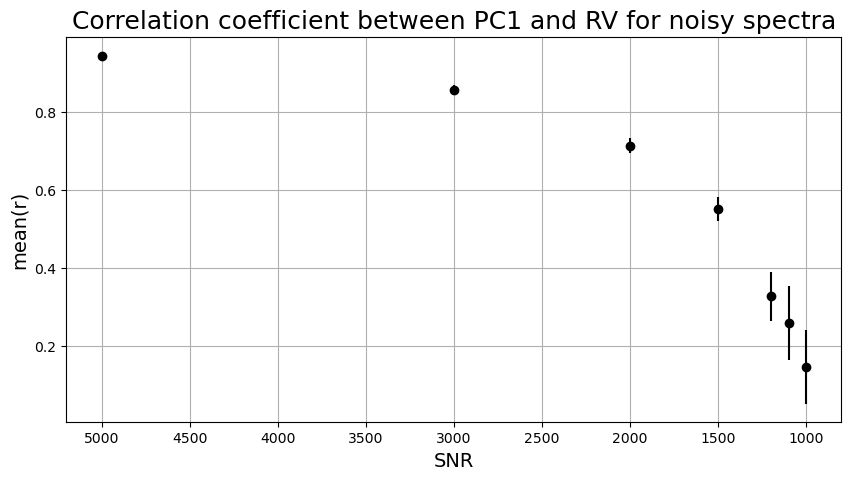

In [230]:
fig, ax = plt.subplots(figsize=(10, 5))

snr_r = data_r['snr'].to_numpy()[2:]
mean_r = data_r['mean_r'].to_numpy()[2:]
std_r = data_r['std_r'].to_numpy()[2:]

ax.errorbar(snr_r, mean_r, yerr=std_r, fmt='o', color='k')
ax.set_title('Correlation coefficient between PC1 and RV for noisy spectra', size=18)
ax.set_xlabel('SNR', size=14)
ax.set_ylabel('mean(r)', size=14)
ax.grid()
ax.xaxis.set_inverted(True)
plt.show()